# Barcelona feature-ablation study — regression

Retrains the three Barcelona regressors (Linear Regression, XGBoost, Random Forest) on the
**`noise_day` (dB)** target with feature groups removed (and used alone). Same 5 groups,
13 configurations and fixed split as the classification ablation (incl. the two combined
configs `-distances-centrality` and `only-distances+centrality`).

**full** must reproduce the published baseline: LinReg R² 0.461 / XGB 0.681 / RF 0.704.

This notebook runs **after** `ablation_classification.ipynb` and also builds the three cross-task
diagrams (leave-one-out importance, single-group standalone power, scale-dependence) from both CSVs.

## Data and libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [2]:
data = pd.read_csv("../../notebooks/_elena/data/bcn_noise_regre_ml_dataset.csv")
data = data.dropna(how="any").reset_index(drop=True)
y = data['noise_day'].to_numpy(dtype=float)
print('rows:', len(data), '| dB range:', y.min(), '-', y.max())

rows: 12854 | dB range: 35.0 - 75.0


## Feature groups and configurations

In [3]:
# Feature groups — the 18 model features partitioned into 5 thematic groups
FEATURE_GROUPS = {
    'core':       ['road_category', 'width'],
    'distances':  ['dist_to_trunk', 'dist_to_primary', 'dist_to_secondary',
                   'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street'],
    'points':     ['signals', 'transport', 'pois'],
    'centrality': ['betweenness', 'closeness_global', 'closeness_400', 'straightness'],
    'landuse':    ['green', 'industrial', 'commercial'],
}
ALL_FEATURES = [f for g in FEATURE_GROUPS.values() for f in g]
assert len(ALL_FEATURES) == 18

# Build the configurations: full + leave-one-group-out + single-group-only,
# plus the two combined configs that isolate the transfer-unstable feature groups
# (distances + centrality go out-of-distribution across cities — see the transfer report).
group_order = ['landuse', 'centrality', 'points', 'distances', 'core']
configs = {'full': ALL_FEATURES}
for g in group_order:
    configs[f'-{g}'] = [f for f in ALL_FEATURES if f not in FEATURE_GROUPS[g]]
# combined removal: drop both scale-dependent groups -> local / scale-invariant features only
configs['-distances-centrality'] = (FEATURE_GROUPS['core'] + FEATURE_GROUPS['points']
                                    + FEATURE_GROUPS['landuse'])
for g in group_order:
    configs[f'only-{g}'] = list(FEATURE_GROUPS[g])
# combined keep: only the scale-dependent groups (the network-size-driven features)
configs['only-distances+centrality'] = FEATURE_GROUPS['distances'] + FEATURE_GROUPS['centrality']

for name, feats in configs.items():
    print(f'{name:24s} {len(feats):2d} features')

full                     18 features
-landuse                 15 features
-centrality              14 features
-points                  15 features
-distances               12 features
-core                    16 features
-distances-centrality     8 features
only-landuse              3 features
only-centrality           4 features
only-points               3 features
only-distances            6 features
only-core                 2 features
only-distances+centrality 10 features


## Run the ablation

In [4]:
def make_models():
    return {
        'Linear Regression': LinearRegression(),
        'XGBoost': xgb.XGBRegressor(),
        'Random Forest': RandomForestRegressor(random_state=42),
    }

rows = []
for cfg_name, feats in configs.items():
    X_scaled = StandardScaler().fit_transform(data[feats])
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
    for mname, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rows.append({
            'config': cfg_name,
            'n_features': len(feats),
            'model': mname,
            'r2': r2_score(y_te, y_pred),
            'mae': mean_absolute_error(y_te, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_te, y_pred)),
        })
    print('done:', cfg_name)

results = pd.DataFrame(rows)
os.makedirs('../results', exist_ok=True)
results.to_csv('../results/ablation_regression_results.csv', index=False)
results.round(4)

done: full


done: -landuse


done: -centrality


done: -points


done: -distances


...

done: only-points


done: only-distances


done: only-core


done: only-distances+centrality


,config,n_features,model,r2,mae,rmse
0,full,18,Linear Regression,0.4610,4.0987,5.1905
1,full,18,XGBoost,0.6811,3.0651,3.9926
2,full,18,Random Forest,0.7041,2.8941,3.8457
3,-landuse,15,Linear Regression,0.4511,4.1340,5.2378
4,-landuse,15,XGBoost,0.6818,3.0419,3.9879
5,-landuse,15,Random Forest,0.7029,2.8980,3.8536
6,-centrality,14,Linear Regression,0.4296,4.2200,5.3397
7,-centrality,14,XGBoost,0.6485,3.2057,4.1912
8,-centrality,14,Random Forest,0.6902,3.0042,3.9348
9,-points,15,Linear Regression,0.4398,4.2068,5.2914


### Pivot — R² by config and model

In [5]:
r2_pivot = results.pivot(index='config', columns='model', values='r2')
r2_pivot = r2_pivot.reindex(list(configs.keys()))
r2_pivot.round(4)

model,Linear Regression,Random Forest,XGBoost
config,,,
full,0.4610,0.7041,0.6811
-landuse,0.4511,0.7029,0.6818
-centrality,0.4296,0.6902,0.6485
-points,0.4398,0.6970,0.6770
-distances,0.4375,0.6660,0.6257
-core,0.4223,0.7043,0.6873
-distances-centrality,0.3048,0.4905,0.4595
only-landuse,0.0560,-0.0198,0.0659
only-centrality,0.3012,0.5948,0.5296


## Figure — metrics per configuration

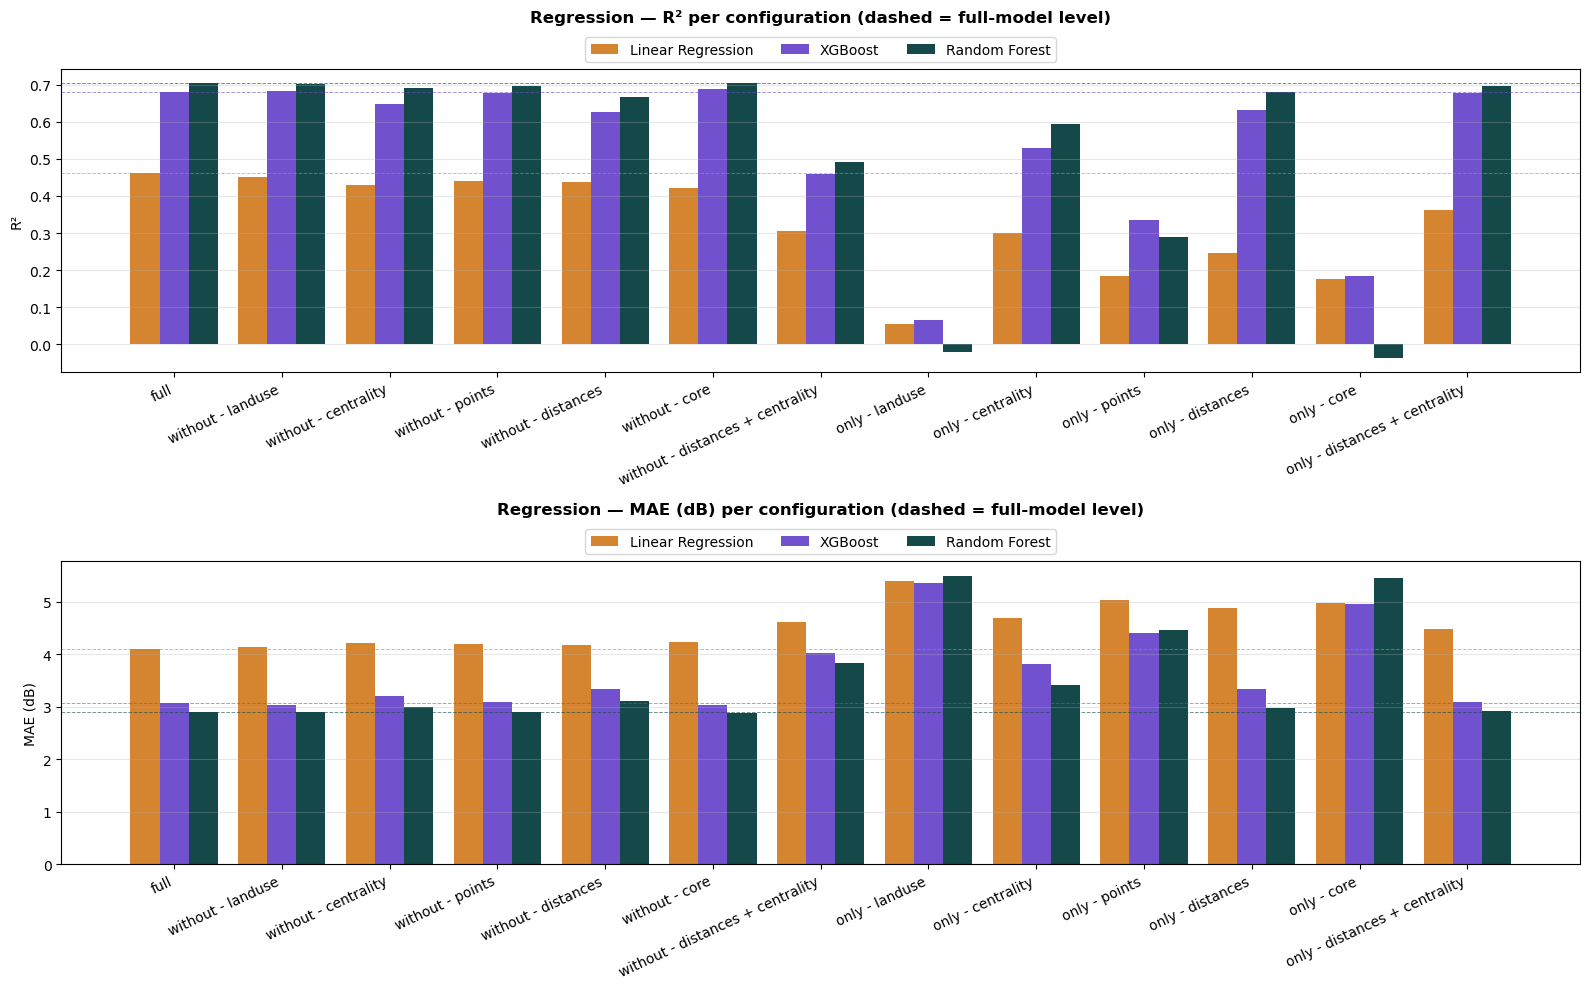

In [6]:
colors = ['#d58430', '#7251ce', '#144849']
models = ['Linear Regression', 'XGBoost', 'Random Forest']
order = list(configs.keys())
def disp_label(c):
    if c == 'full':
        return 'full'
    if c.startswith('only-'):
        return 'only - ' + c[5:].replace('+', ' + ')
    return 'without - ' + c[1:].replace('-', ' + ')
labels = [disp_label(c) for c in order]
x = np.arange(len(order)); w = 0.27

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for metric, ax, title in [('r2', axes[0], 'R²'), ('mae', axes[1], 'MAE (dB)')]:
    piv = results.pivot(index='config', columns='model', values=metric).reindex(order)
    for i, m in enumerate(models):
        ax.bar(x + (i - 1) * w, piv[m].values, w, label=m, color=colors[i])
    for i, m in enumerate(models):
        ax.axhline(piv.loc['full', m], ls='--', lw=0.7, color=colors[i], alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right')
    ax.set_title(f'Regression — {title} per configuration (dashed = full-model level)',
                 fontsize=12, fontweight='bold', pad=34)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
plt.tight_layout()
plt.savefig('../results/fig_regre_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-task diagrams

In [7]:
cls = pd.read_csv('../results/ablation_classification_results.csv')
reg = pd.read_csv('../results/ablation_regression_results.csv')

groups = ['landuse', 'centrality', 'points', 'distances', 'core']
models_cls = ['Logistic Regression', 'XGBoost', 'Random Forest']
models_reg = ['Linear Regression', 'XGBoost', 'Random Forest']
gx = np.arange(len(groups)); w = 0.27

### Leave-one-group-out importance
How much performance is **lost** when each group is removed from the full model
(`full − ablated`). Bigger drop = the model relies on that group more.

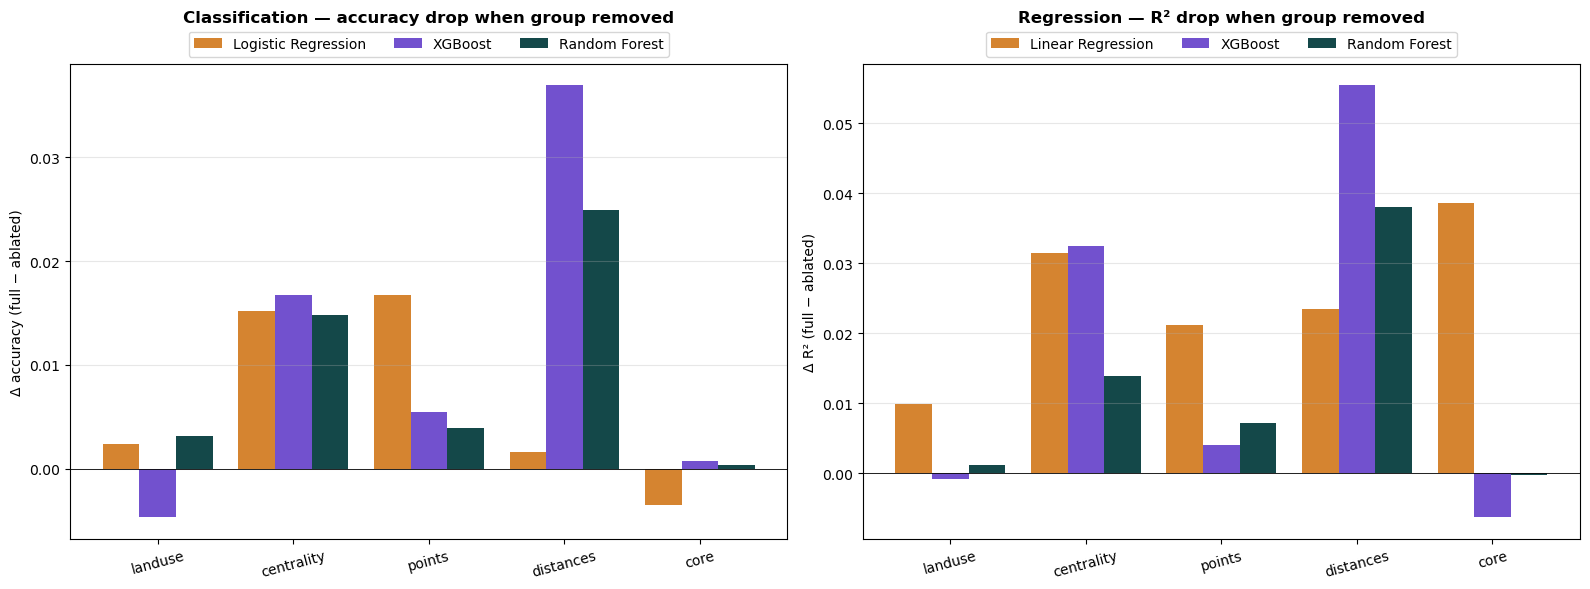

In [8]:
colors = ['#d58430', '#7251ce', '#144849']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

full_acc = cls[cls.config == 'full'].set_index('model')['accuracy']
for i, m in enumerate(models_cls):
    deltas = [full_acc[m] - cls[(cls.config == f'-{g}') & (cls.model == m)]['accuracy'].values[0]
              for g in groups]
    axes[0].bar(gx + (i - 1) * w, deltas, w, label=m, color=colors[i])
axes[0].set_xticks(gx); axes[0].set_xticklabels(groups, rotation=15)
axes[0].set_title('Classification — accuracy drop when group removed', fontweight='bold', pad=30)
axes[0].set_ylabel('Δ accuracy (full − ablated)')
axes[0].axhline(0, color='k', lw=0.6); axes[0].grid(axis='y', alpha=0.3); axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

full_r2 = reg[reg.config == 'full'].set_index('model')['r2']
for i, m in enumerate(models_reg):
    deltas = [full_r2[m] - reg[(reg.config == f'-{g}') & (reg.model == m)]['r2'].values[0]
              for g in groups]
    axes[1].bar(gx + (i - 1) * w, deltas, w, label=m, color=colors[i])
axes[1].set_xticks(gx); axes[1].set_xticklabels(groups, rotation=15)
axes[1].set_title('Regression — R² drop when group removed', fontweight='bold', pad=30)
axes[1].set_ylabel('Δ R² (full − ablated)')
axes[1].axhline(0, color='k', lw=0.6); axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

plt.tight_layout()
plt.savefig('../results/fig_leave_one_out.png', dpi=150, bbox_inches='tight')
plt.show()

### Single-group-only standalone power
How well each group predicts noise **on its own** (no other features).
Dashed line = the full-model level for reference.

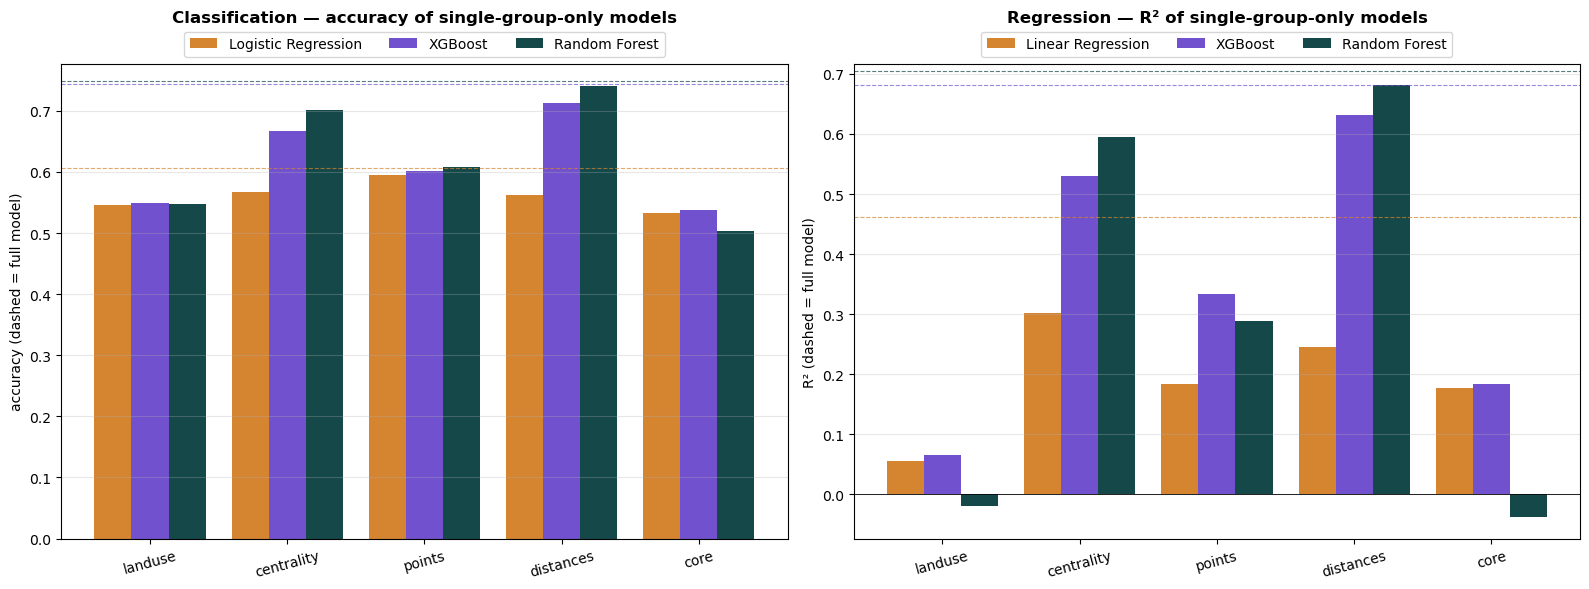

In [9]:
colors = ['#d58430', '#7251ce', '#144849']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, m in enumerate(models_cls):
    vals = [cls[(cls.config == f'only-{g}') & (cls.model == m)]['accuracy'].values[0] for g in groups]
    axes[0].bar(gx + (i - 1) * w, vals, w, label=m, color=colors[i])
for i, m in enumerate(models_cls):
    axes[0].axhline(full_acc[m], ls='--', lw=0.8, color=colors[i], alpha=0.7)
axes[0].set_xticks(gx); axes[0].set_xticklabels(groups, rotation=15)
axes[0].set_title('Classification — accuracy of single-group-only models', fontweight='bold', pad=30)
axes[0].set_ylabel('accuracy (dashed = full model)')
axes[0].grid(axis='y', alpha=0.3); axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

for i, m in enumerate(models_reg):
    vals = [reg[(reg.config == f'only-{g}') & (reg.model == m)]['r2'].values[0] for g in groups]
    axes[1].bar(gx + (i - 1) * w, vals, w, label=m, color=colors[i])
for i, m in enumerate(models_reg):
    axes[1].axhline(full_r2[m], ls='--', lw=0.8, color=colors[i], alpha=0.7)
axes[1].set_xticks(gx); axes[1].set_xticklabels(groups, rotation=15)
axes[1].set_title('Regression — R² of single-group-only models', fontweight='bold', pad=30)
axes[1].set_ylabel('R² (dashed = full model)')
axes[1].axhline(0, color='k', lw=0.6); axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

plt.tight_layout()
plt.savefig('../results/fig_single_group.png', dpi=150, bbox_inches='tight')
plt.show()

### Scale-invariant vs scale-dependent features (transfer relevance)
`distances` and `centrality` are exactly the groups that go out-of-distribution across cities
(network size / urban fabric). This compares three models: the **full** 18-feature model, the
**local / scale-invariant** 8-feature model (`-distances-centrality`: core + points + landuse), and
the **network-scale** 10-feature model (`only-distances+centrality`). The gap between full and
local-only is the Barcelona accuracy that lives in the non-transferable features.

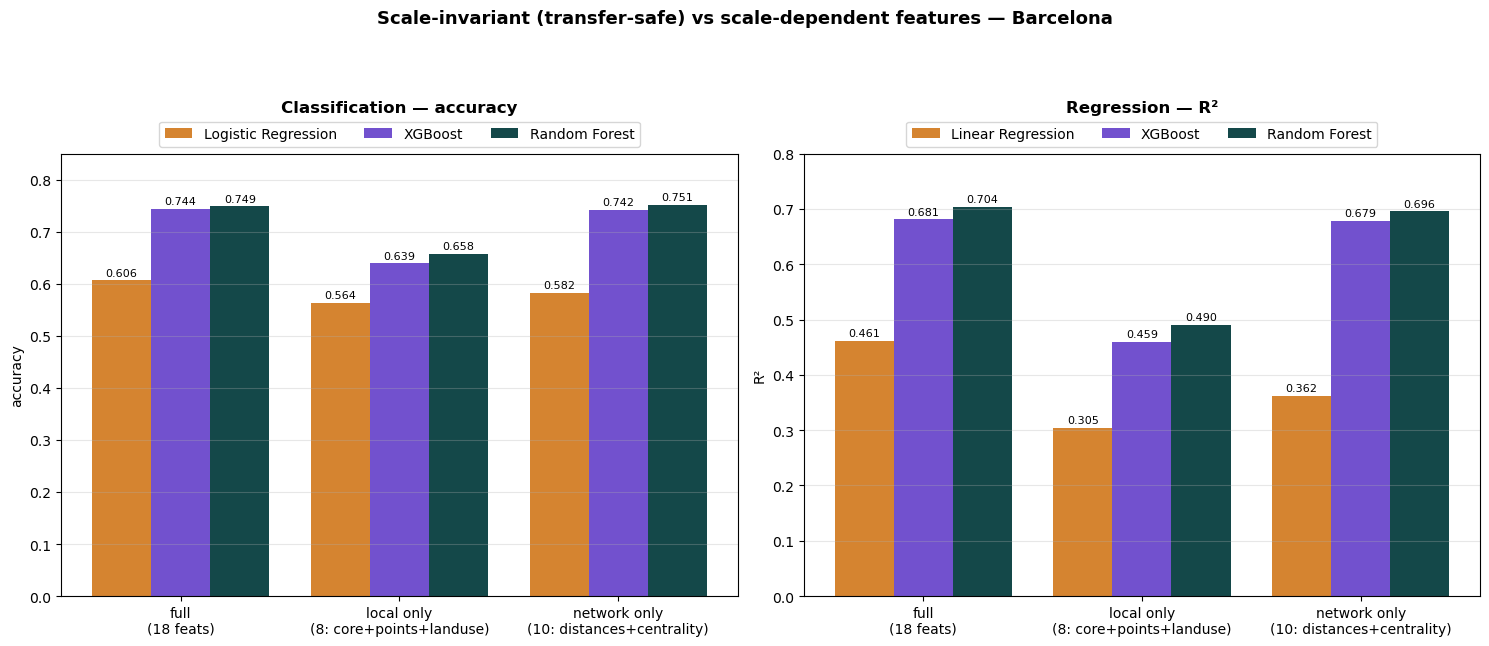

In [10]:
colors = ['#d58430', '#7251ce', '#144849']
sd_configs = ['full', '-distances-centrality', 'only-distances+centrality']
sd_labels = ['full\n(18 feats)', 'local only\n(8: core+points+landuse)',
             'network only\n(10: distances+centrality)']
sx = np.arange(len(sd_configs)); w = 0.27

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, m in enumerate(models_cls):
    vals = [cls[(cls.config == c) & (cls.model == m)]['accuracy'].values[0] for c in sd_configs]
    bars = axes[0].bar(sx + (i - 1) * w, vals, w, label=m, color=colors[i])
    axes[0].bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
axes[0].set_xticks(sx); axes[0].set_xticklabels(sd_labels)
axes[0].set_title('Classification — accuracy', fontweight='bold', pad=30)
axes[0].set_ylabel('accuracy'); axes[0].set_ylim(0, 0.85)
axes[0].grid(axis='y', alpha=0.3); axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

for i, m in enumerate(models_reg):
    vals = [reg[(reg.config == c) & (reg.model == m)]['r2'].values[0] for c in sd_configs]
    bars = axes[1].bar(sx + (i - 1) * w, vals, w, label=m, color=colors[i])
    axes[1].bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
axes[1].set_xticks(sx); axes[1].set_xticklabels(sd_labels)
axes[1].set_title('Regression — R²', fontweight='bold', pad=30)
axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 0.8)
axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)

fig.suptitle('Scale-invariant (transfer-safe) vs scale-dependent features — Barcelona',
             fontsize=13, fontweight='bold', y=1.07)
plt.tight_layout()
plt.savefig('../results/fig_scale_dependence.png', dpi=150, bbox_inches='tight')
plt.show()